In [2]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

In [3]:
dataset_path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")

csv_file = next(f for f in os.listdir(dataset_path) if f.endswith('.csv'))

df = pd.read_csv(os.path.join(dataset_path, csv_file))

print(f"Розмірність датасету: {df.shape}")

df.head()

Розмірність датасету: (232725, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
scaler = StandardScaler()
colsToScale = ['danceability', 'energy', 'loudness', 'speechiness', 
                 'acousticness', 'instrumentalness', 'liveness', 
                 'valence', 'tempo', 'duration_ms']
df[colsToScale] = scaler.fit_transform(df[colsToScale])

df_popular = df[df['popularity'] >= 85].copy()
print(f"Розмірність таблиці: {df_popular.shape}")
df_popular.head()

Розмірність таблиці: (417, 18)


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,-0.920210,0.924721,-0.375685,-0.064366,-0.489819,F,-0.549796,0.713529,Minor,-0.156670,1.693669,4/4,-0.461104
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.590358,0.919334,-0.474898,-0.948768,-0.489819,C#,-0.638563,-0.195745,Minor,1.090110,-1.538070,4/4,-0.522627
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,-0.201711,1.064802,-0.281340,-0.314884,-0.489788,F#,-0.612337,0.420108,Major,-0.270944,0.594664,4/4,0.300245
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,1.159745,0.499093,-0.534317,-0.994317,-0.489794,G,-0.065613,0.270396,Minor,-0.453676,-0.991027,4/4,-0.999431
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.232376,1.037863,-0.446648,-0.428755,-0.489819,F#,0.186565,0.446616,Major,0.982304,-1.379909,4/4,0.057998


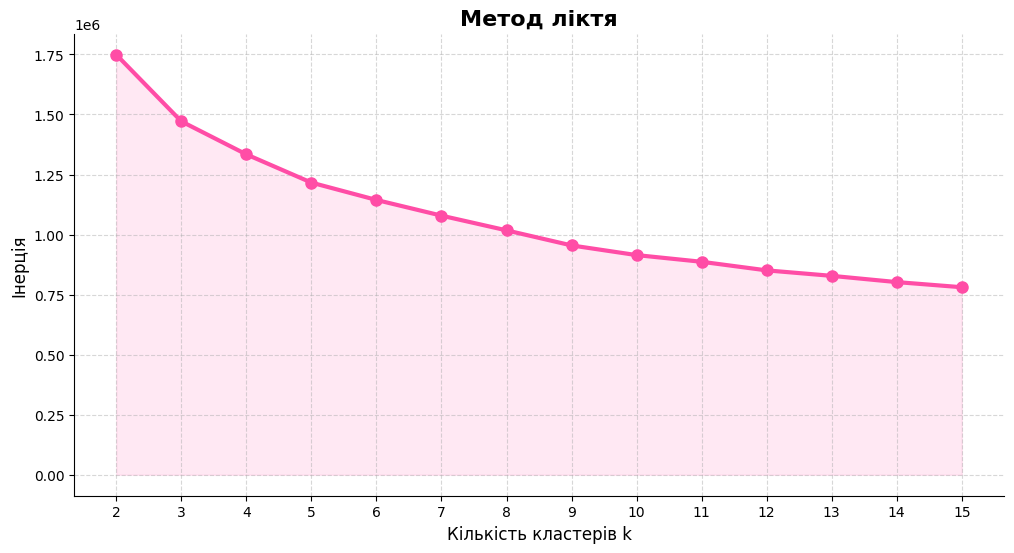

In [5]:
df_scaled = df.copy()
features = ['danceability', 'energy', 'loudness', 'speechiness',
            'acousticness', 'instrumentalness', 'liveness',
            'valence', 'tempo', 'duration_ms']

X = df_scaled[features]

inertias = []
k_range = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(k_range, inertias, marker='o',
         color='#ff4da6', linewidth=3, markersize=8)
plt.fill_between(k_range, inertias,
                 color='#ffb3d9', alpha=0.3)
plt.xlabel('Кількість кластерів k', fontsize=12)
plt.ylabel('Інерція', fontsize=12)
plt.title('Метод ліктя', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(k_range)
plt.tick_params(axis='both', labelsize=10)
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.show()

In [6]:
optimal_k = 6

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_scaled['cluster'] = kmeans.fit_predict(X)

df_popular = df_scaled[df['popularity'] >= 85].copy()

print(df_scaled['cluster'].value_counts().sort_index())
print("Приклади пісень по кластерах:")
df_popular[['artist_name', 'track_name', 'cluster']].head(10)

cluster
0    10111
1    80265
2    24067
3    59745
4    41760
5    16777
Name: count, dtype: int64
Приклади пісень по кластерах:


,artist_name,track_name,cluster
9026,Ariana Grande,"break up with your girlfriend, i'm bored",3
9027,Ariana Grande,7 rings,4
9028,Halsey,Without Me,1
9029,Ariana Grande,needy,4
9030,Ariana Grande,NASA,1
9031,Ariana Grande,"thank u, next",1
9032,Ariana Grande,bloodline,1
9033,Ariana Grande,bad idea,1
9034,benny blanco,Eastside (with Halsey & Khalid),1
9035,Ariana Grande,fake smile,1


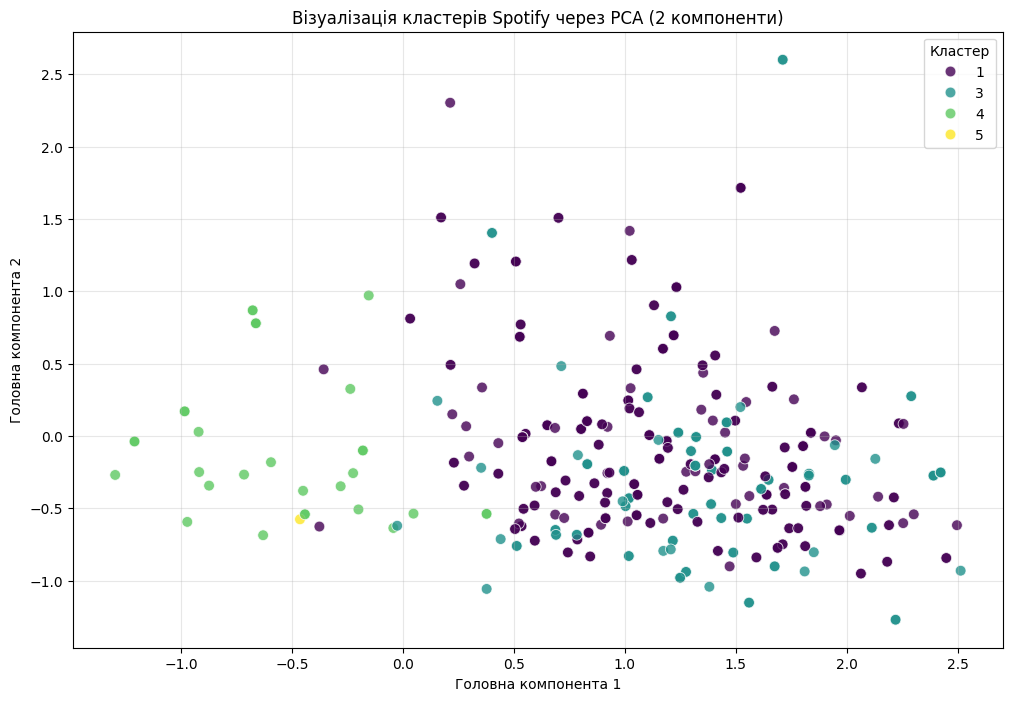

In [10]:
pca2d = PCA(n_components=2)
pca_data2d = pca2d.fit_transform(X)

df_popular = df_scaled[df_scaled['popularity'] >= 85].copy()

df_popular['pca1_2d'] = pca_data2d[df_scaled['popularity'] >= 85, 0]
df_popular['pca2_2d'] = pca_data2d[df_scaled['popularity'] >= 85, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='pca1_2d', y='pca2_2d',
    hue='cluster',
    palette='viridis',
    data=df_popular,
    s=60, alpha=0.8
)

plt.title('Візуалізація кластерів Spotify через PCA (2 компоненти)')
plt.xlabel('Головна компонента 1')
plt.ylabel('Головна компонента 2')
plt.legend(title='Кластер')
plt.grid(True, alpha=0.3)
plt.show()

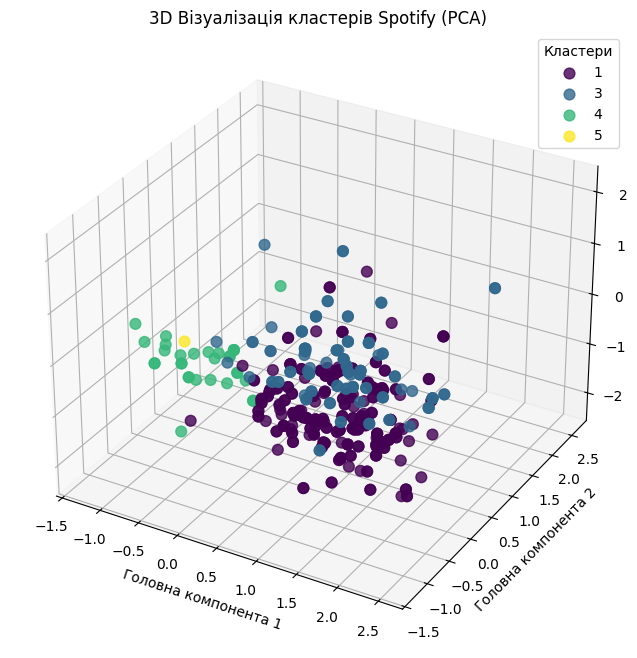

In [12]:
# --- PCA 3D ---
pca3d = PCA(n_components=3)
pca_data3d = pca3d.fit_transform(X)

mask = df_scaled['popularity'] >= 85

df_popular['pca1_3d'] = pca_data3d[mask, 0]
df_popular['pca2_3d'] = pca_data3d[mask, 1]
df_popular['pca3_3d'] = pca_data3d[mask, 2]

clusters = df_popular['cluster'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))
color_map = dict(zip(sorted(clusters), colors))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster_id in sorted(clusters):
    mask_c = df_popular['cluster'] == cluster_id
    ax.scatter(
        df_popular.loc[mask_c, 'pca1_3d'],
        df_popular.loc[mask_c, 'pca2_3d'],
        df_popular.loc[mask_c, 'pca3_3d'],
        c=[color_map[cluster_id]],
        label=str(cluster_id),
        s=60, alpha=0.8
    )

ax.set_title('3D Візуалізація кластерів Spotify (PCA)')
ax.set_xlabel('Головна компонента 1')
ax.set_ylabel('Головна компонента 2')
ax.set_zlabel('Головна компонента 3')
ax.legend(title='Кластери')
plt.show()

Середні значення ознак по кластерах:
         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
1            1.113449  0.239082  0.599563     0.063463     -0.454193   
3            0.577166  0.472693  0.674308     0.044601     -0.742165   
4            0.227622 -0.662008  0.248265    -0.131857      0.694833   
5            0.224320 -0.071958 -0.118055    -0.128101     -0.823245   

         instrumentalness  liveness   valence     tempo  duration_ms  
cluster                                                               
1               -0.482235 -0.283422  0.255652 -0.289379    -0.319012  
3               -0.484336 -0.020163 -0.123938  1.193497    -0.209493  
4               -0.486361 -0.433631 -0.610061 -0.453272    -0.259451  
5                0.613337 -0.559883 -1.318582 -0.638133    -0.048786  


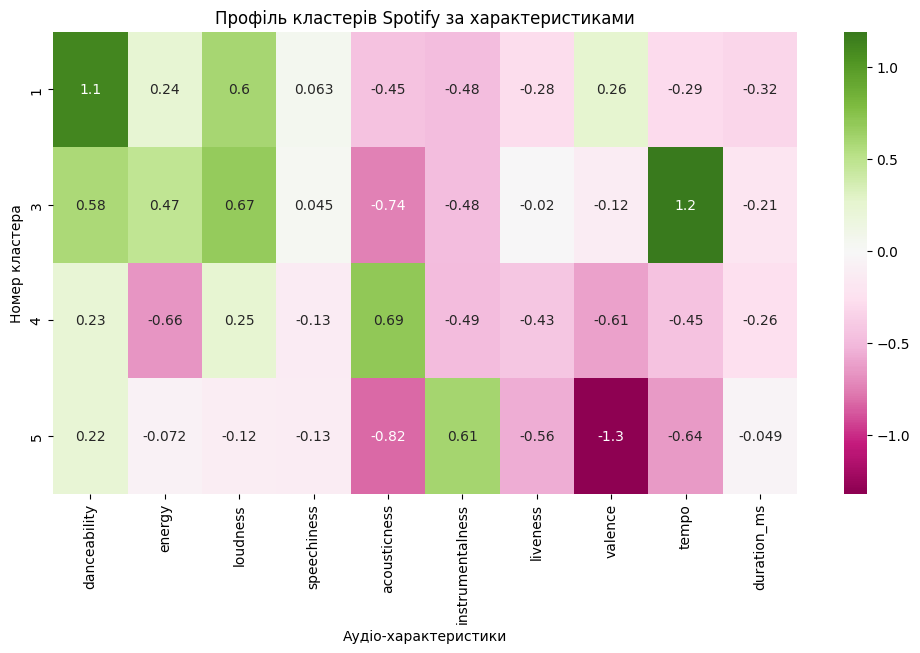

In [14]:
cluster_features = df_popular.groupby('cluster')[colsToScale].mean()

print("Середні значення ознак по кластерах:")
print(cluster_features)

plt.figure(figsize=(12, 6))
sns.heatmap(
    cluster_features,
    annot=True,
    cmap='PiYG',
    center=0
)
plt.title('Профіль кластерів Spotify за характеристиками')
plt.xlabel('Аудіо-характеристики')
plt.ylabel('Номер кластера')
plt.show()